# 02 - Classical Baselines

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Trains all four classical baselines (Logistic Regression, Random Forest, XGBoost, LightGBM)
on the ULB schema and compares them on the metrics that actually matter for a ~1-2% fraud
rate: **PR-AUC**, recall, precision, F1, and FPR — never accuracy (see `docs/methodology.md`).

In [2]:
from src.data.loaders import load_dataset, load_synthetic
from src.data.preprocessing import clean_dataframe, fit_transform_split, infer_feature_types, random_split
from src.classical.logistic_regression import LogisticRegressionModel
from src.classical.random_forest import RandomForestModel
from src.classical.xgboost_model import XGBoostModel
from src.classical.lightgbm_model import LightGBMModel
from src.evaluation.metrics import compute_metrics
from src.classical.calibration import tune_threshold_expected_loss

try:
    ds = load_dataset("ulb")
except FileNotFoundError:
    ds = load_synthetic("ulb", n_samples=8000, random_state=42)
print("is_synthetic:", ds.is_synthetic)

frame = clean_dataframe(ds.frame, ds.target)
numeric, categorical = infer_feature_types(frame, ds.target, ds.categorical_features)
splits = random_split(frame, ds.target, test_size=0.2, validation_size=0.1, random_state=42)
X_train, X_others, transformer, meta = fit_transform_split(
    splits["train"], {"test": splits["test"]}, ds.target, numeric, categorical
)
y_train, y_test = splits["train"][ds.target].values, splits["test"][ds.target].values
X_test = X_others["test"]
print(f"train={len(y_train)}  test={len(y_test)}  features={X_train.shape[1]}")


is_synthetic: True


train=5600  test=1600  features=30


In [3]:
MODELS = {
    "Logistic Regression": LogisticRegressionModel,
    "Random Forest": RandomForestModel,
    "XGBoost": XGBoostModel,
    "LightGBM": LightGBMModel,
}

rows = []
proba_by_model = {}
for name, Cls in MODELS.items():
    model = Cls(calibrate=False)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)
    proba_by_model[name] = proba
    thr = tune_threshold_expected_loss(y_test, proba, fraud_loss=500, false_positive_cost=25)
    m = compute_metrics(y_test, proba, threshold=thr.threshold)
    rows.append({"model": name, "pr_auc": m.pr_auc, "recall": m.recall, "precision": m.precision,
                 "f1": m.f1, "fpr": m.fpr, "threshold": thr.threshold})

results_df = pd.DataFrame(rows).set_index("model")
results_df.round(4)


,pr_auc,recall,precision,f1,fpr,threshold
model,,,,,,
Logistic Regression,0.7501,0.8214,0.4423,0.5750,0.0184,0.8141
Random Forest,0.9378,0.9643,0.7297,0.8308,0.0064,0.1759
XGBoost,0.9349,0.9286,0.9286,0.9286,0.0013,0.0754
LightGBM,0.9695,0.8571,0.9231,0.8889,0.0013,0.0050


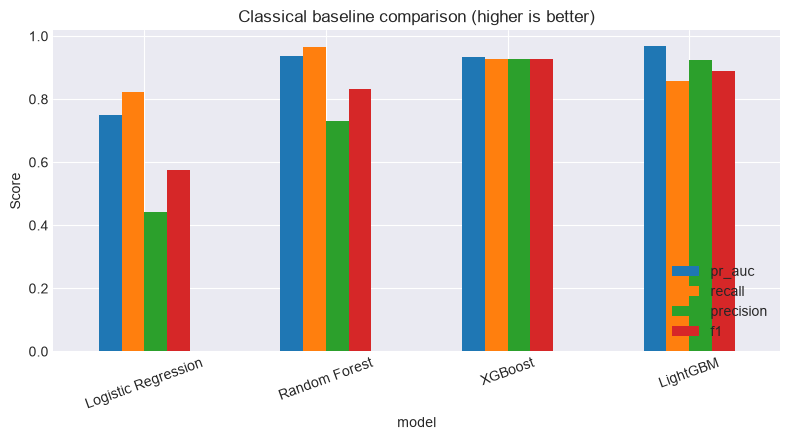

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
results_df[["pr_auc", "recall", "precision", "f1"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Classical baseline comparison (higher is better)")
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\02_classical_comparison.png")
plt.show()


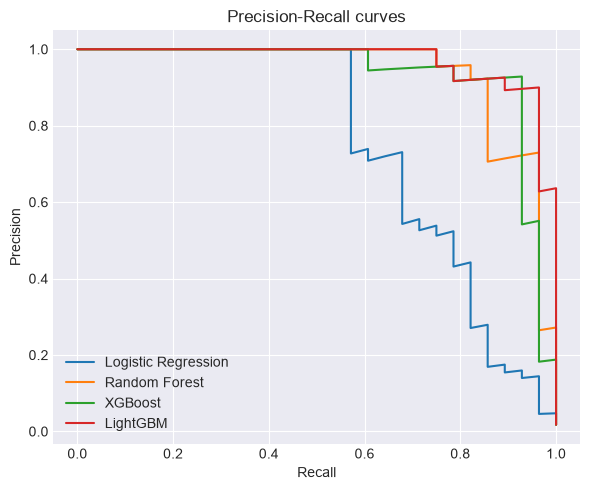

In [5]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in proba_by_model.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    ax.plot(r, p, label=name)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves")
ax.legend()
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\02_pr_curves.png")
plt.show()


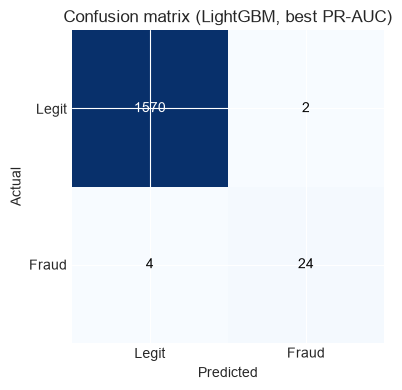

Best model by PR-AUC: LightGBM


In [6]:
from sklearn.metrics import confusion_matrix

best_name = results_df["pr_auc"].idxmax()
best_proba = proba_by_model[best_name]
best_threshold = results_df.loc[best_name, "threshold"]
cm = confusion_matrix(y_test, (best_proba >= best_threshold).astype(int))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Legit", "Fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Legit", "Fraud"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix ({best_name}, best PR-AUC)")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\02_confusion_matrix.png")
plt.show()
print(f"Best model by PR-AUC: {best_name}")
